In [1]:

from pathlib import Path
import sys
import json
import pandas as pd
import numpy as np

pd.set_option('display.max_columns', 160)
pd.set_option('display.max_colwidth', 180)


def find_project_root(start=None) -> Path:
    start = Path(start or Path.cwd()).resolve()
    candidates = [start] + list(start.parents)
    for p in candidates:
        if (p / 'src' / 'neoolaf').exists():
            return p
    for p in candidates:
        if (p / 'pyproject.toml').exists() and (p / 'examples' / 'XQualityMachine32').exists():
            return p
    raise RuntimeError('Could not find NeoOLAF project root. Run this notebook from inside the NeoOLAF repo.')

PROJECT_ROOT = find_project_root()
SRC_DIR = PROJECT_ROOT / 'src'
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

EXAMPLE_ROOT = PROJECT_ROOT / 'examples' / 'XQualityMachine32'
RUNS_ROOT = EXAMPLE_ROOT / 'runs'
MACHINE32_DIR = PROJECT_ROOT / 'data' / 'XQuality' / 'Machine32'
OUTPUT_DIR = RUNS_ROOT / 'olaf_semantic_validation_metrics_v2_strict_cv'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print('PROJECT_ROOT:', PROJECT_ROOT)
print('MACHINE32_DIR:', MACHINE32_DIR)
print('OUTPUT_DIR:', OUTPUT_DIR)

if not MACHINE32_DIR.exists():
    raise FileNotFoundError(f'MACHINE32_DIR does not exist: {MACHINE32_DIR}')


PROJECT_ROOT: C:\Users\henri\Documents\git\post-doc\NeoOLAF
MACHINE32_DIR: C:\Users\henri\Documents\git\post-doc\NeoOLAF\data\XQuality\Machine32
OUTPUT_DIR: C:\Users\henri\Documents\git\post-doc\NeoOLAF\examples\XQualityMachine32\runs\olaf_semantic_validation_metrics_v2_strict_cv


In [2]:

try:
    from neoolaf.evaluation.metrics.semantic_validation_metrics import (
        SemanticValidationConfig,
        load_triple_table,
        compute_semantic_validation_metrics,
    )
    print('Imported semantic_validation_metrics v2 from src/neoolaf/evaluation/metrics/semantic_validation_metrics.py')
except Exception as exc:
    raise ImportError(
        'Could not import semantic_validation_metrics. Copy the v2 patch into the repo root, '
        'restart the kernel, and run again. Original error: ' + repr(exc)
    )


Imported semantic_validation_metrics v2 from src/neoolaf/evaluation/metrics/semantic_validation_metrics.py


In [3]:

def find_first(root: Path, patterns, required=True):
    hits = []
    for pat in patterns:
        hits.extend(root.rglob(pat))
    # prefer paths containing output/ for generated OLAF files
    hits = sorted(set(hits), key=lambda p: (0 if 'output' in str(p).lower() else 1, len(str(p))))
    if hits:
        return hits[0]
    if required:
        raise FileNotFoundError(f'Could not find any of {patterns} under {root}')
    return None

OLAF_TRIPLES_PATH = find_first(MACHINE32_DIR, ['llm_alarm_triplets.xlsx', '*triplet*.xlsx', '*triple*.xlsx'])
OLAF_ONTOLOGY_PATH = find_first(MACHINE32_DIR, ['llm_alarm_ontology.ttl', '*ontology*.ttl', '*.ttl'])
OLAF_SOURCE_TEXT_PATH = find_first(MACHINE32_DIR, ['alarm.txt', '*alarm*.txt'], required=False)

print('OLAF_TRIPLES_PATH:', OLAF_TRIPLES_PATH)
print('OLAF_ONTOLOGY_PATH:', OLAF_ONTOLOGY_PATH)
print('OLAF_SOURCE_TEXT_PATH:', OLAF_SOURCE_TEXT_PATH)


OLAF_TRIPLES_PATH: C:\Users\henri\Documents\git\post-doc\NeoOLAF\data\XQuality\Machine32\OLAF\output\llm_alarm_triplets.xlsx
OLAF_ONTOLOGY_PATH: C:\Users\henri\Documents\git\post-doc\NeoOLAF\data\XQuality\Machine32\OLAF\output\llm_alarm_ontology.ttl
OLAF_SOURCE_TEXT_PATH: C:\Users\henri\Documents\git\post-doc\NeoOLAF\data\XQuality\Machine32\OLAF\data\XQuality\alarm.txt


In [4]:

CONFIG_STRICT = SemanticValidationConfig(
    node_fuzzy_threshold=0.92,
    predicate_fuzzy_threshold=0.90,
    allow_lexical_source_support_for_str=False,
    cv_mode='strict_schema',
    require_domain_and_range_for_strict_cv=True,
    count_invalid_rows_in_cv=False,
    dvs_min_str=0.95,
    dvs_max_cr=0.05,
    dvs_min_pc=0.95,
    dvs_min_oc=0.95,
    dvs_max_cv=0.05,
)

CONFIG_OBSERVED = SemanticValidationConfig(
    node_fuzzy_threshold=0.92,
    predicate_fuzzy_threshold=0.90,
    allow_lexical_source_support_for_str=False,
    cv_mode='observed_alignment',
    require_domain_and_range_for_strict_cv=True,
    count_invalid_rows_in_cv=False,
    dvs_min_str=0.95,
    dvs_max_cr=0.05,
    dvs_min_pc=0.95,
    dvs_min_oc=0.95,
    dvs_max_cv=0.05,
)

print('Strict config:', CONFIG_STRICT)
print('Observed config:', CONFIG_OBSERVED)


Strict config: SemanticValidationConfig(node_fuzzy_threshold=0.92, predicate_fuzzy_threshold=0.9, allow_lexical_source_support_for_str=False, min_label_chars_for_source_match=3, cv_mode='strict_schema', require_domain_and_range_for_strict_cv=True, count_invalid_rows_in_cv=False, dvs_min_str=0.95, dvs_max_cr=0.05, dvs_min_pc=0.95, dvs_min_oc=0.95, dvs_max_cv=0.05)
Observed config: SemanticValidationConfig(node_fuzzy_threshold=0.92, predicate_fuzzy_threshold=0.9, allow_lexical_source_support_for_str=False, min_label_chars_for_source_match=3, cv_mode='observed_alignment', require_domain_and_range_for_strict_cv=True, count_invalid_rows_in_cv=False, dvs_min_str=0.95, dvs_max_cr=0.05, dvs_min_pc=0.95, dvs_min_oc=0.95, dvs_max_cv=0.05)


In [5]:

olaf_df = load_triple_table(OLAF_TRIPLES_PATH)
print('Raw OLAF table shape:', olaf_df.shape)
display(olaf_df.head(20))

strict_summary, strict_details_df = compute_semantic_validation_metrics(
    triples_df=olaf_df,
    ontology_path=OLAF_ONTOLOGY_PATH,
    source_text_path=OLAF_SOURCE_TEXT_PATH,
    config=CONFIG_STRICT,
)

observed_summary, observed_details_df = compute_semantic_validation_metrics(
    triples_df=olaf_df,
    ontology_path=OLAF_ONTOLOGY_PATH,
    source_text_path=OLAF_SOURCE_TEXT_PATH,
    config=CONFIG_OBSERVED,
)

summary_df = pd.DataFrame([strict_summary])
summary_df.insert(0, 'series', 'OLAF')
summary_df.insert(1, 'triple_path', str(OLAF_TRIPLES_PATH))
summary_df.insert(2, 'ontology_path', str(OLAF_ONTOLOGY_PATH))
summary_df.insert(3, 'source_text_path', str(OLAF_SOURCE_TEXT_PATH) if OLAF_SOURCE_TEXT_PATH else '')

# Explicitly keep the old behavior for diagnostic comparison.
summary_df['CV_old_observed_mode'] = observed_summary['CV']
summary_df['DVS_old_observed_mode'] = observed_summary['DVS']

summary_path = OUTPUT_DIR / 'olaf_semantic_validation_summary_v2_strict_cv.csv'
details_path = OUTPUT_DIR / 'olaf_semantic_validation_details_v2_strict_cv.csv'
summary_df.to_csv(summary_path, index=False)
strict_details_df.to_csv(details_path, index=False)

print('Saved:', summary_path)
print('Saved:', details_path)

display(summary_df.T.rename(columns={0: 'value'}))


Raw OLAF table shape: (82, 3)


,Source Node,Target Node,Relation
0,?,?,release
1,?,?,press
2,?,?,signal
3,?,?,Alarm
4,?,?,activation
5,?,?,enable
6,?,?,closed
7,?,?,receiving
8,?,?,ERRONEOUS
9,?,?,concerned by


Saved: C:\Users\henri\Documents\git\post-doc\NeoOLAF\examples\XQualityMachine32\runs\olaf_semantic_validation_metrics_v2_strict_cv\olaf_semantic_validation_summary_v2_strict_cv.csv
Saved: C:\Users\henri\Documents\git\post-doc\NeoOLAF\examples\XQualityMachine32\runs\olaf_semantic_validation_metrics_v2_strict_cv\olaf_semantic_validation_details_v2_strict_cv.csv


,value
series,OLAF
triple_path,C:\Users\henri\Documents\git\post-doc\NeoOLAF\data\XQuality\Machine32\OLAF\output\llm_alarm_triplets.xlsx
ontology_path,C:\Users\henri\Documents\git\post-doc\NeoOLAF\data\XQuality\Machine32\OLAF\output\llm_alarm_ontology.ttl
source_text_path,C:\Users\henri\Documents\git\post-doc\NeoOLAF\data\XQuality\Machine32\OLAF\data\XQuality\alarm.txt
raw_triple_row_count,82
valid_triple_count,11
invalid_or_unresolved_triple_count,71
support_trace_count,0
provenance_count,0
ontology_compliant_triple_count,11


In [6]:
slide_cols = ['series', 'STR', 'CR', 'PC', 'OC', 'CV', 'DVS']
slide_df = summary_df[slide_cols].copy()
for c in ['STR', 'CR', 'PC', 'OC', 'CV', 'DVS']:
    slide_df[c] = slide_df[c].astype(float)

display(slide_df)

latex_row = (
    f"OLAF & {slide_df.iloc[0]['STR']:.4f} & {slide_df.iloc[0]['CR']:.4f} & "
    f"{slide_df.iloc[0]['PC']:.4f} & {slide_df.iloc[0]['OC']:.4f} & "
    f"{slide_df.iloc[0]['CV']:.4f} & {slide_df.iloc[0]['DVS']:.4f} \\"
)
print(latex_row)

latex_path = OUTPUT_DIR / 'olaf_semantic_validation_latex_row_v2_strict_cv.txt'
latex_path.write_text(latex_row, encoding='utf-8')
print('Saved:', latex_path)

,series,STR,CR,PC,OC,CV,DVS
0,OLAF,0.0,0.865854,0.0,1.0,1.0,0.0


OLAF & 0.0000 & 0.8659 & 0.0000 & 1.0000 & 1.0000 & 0.0000 \
Saved: C:\Users\henri\Documents\git\post-doc\NeoOLAF\examples\XQualityMachine32\runs\olaf_semantic_validation_metrics_v2_strict_cv\olaf_semantic_validation_latex_row_v2_strict_cv.txt


In [7]:

explain_cols = [
    'series',
    'raw_triple_row_count',
    'valid_triple_count',
    'invalid_or_unresolved_triple_count',
    'ontology_class_count',
    'ontology_property_count',
    'ontology_properties_with_domain_count',
    'ontology_properties_with_range_count',
    'OC',
    'CV_old_observed_mode',
    'CV_observed_alignment',
    'schema_constraint_coverage',
    'CV_strict_schema',
    'CV',
    'CR',
    'DVS',
]

display(summary_df[[c for c in explain_cols if c in summary_df.columns]])

print('Interpretation:')
print('- CV_observed_alignment is the old behavior: it is zero if valid triples lexically align and no explicit domain/range violation is detected.')
print('- schema_constraint_coverage shows whether valid triples actually have explicit domain/range constraints available.')
print('- CV_strict_schema counts missing domain/range constraints as validation failures, avoiding a fake CV=0 for vocabulary-only ontologies.')


,series,raw_triple_row_count,valid_triple_count,invalid_or_unresolved_triple_count,ontology_class_count,ontology_property_count,ontology_properties_with_domain_count,ontology_properties_with_range_count,OC,CV_old_observed_mode,CV_observed_alignment,schema_constraint_coverage,CV_strict_schema,CV,CR,DVS
0,OLAF,82,11,71,59,77,0,0,1.0,0.0,0.0,0.0,1.0,1.0,0.865854,0.0


Interpretation:
- CV_observed_alignment is the old behavior: it is zero if valid triples lexically align and no explicit domain/range violation is detected.
- schema_constraint_coverage shows whether valid triples actually have explicit domain/range constraints available.
- CV_strict_schema counts missing domain/range constraints as validation failures, avoiding a fake CV=0 for vocabulary-only ontologies.


In [8]:

invalid_df = strict_details_df[~strict_details_df['valid_triple']].copy()
print('Invalid/unresolved examples:')
display(invalid_df.head(30))

missing_schema_df = strict_details_df[
    (strict_details_df['valid_triple'])
    & (strict_details_df['missing_domain_range_constraint'])
].copy()
print('Valid triples without complete domain/range constraints:')
display(missing_schema_df.head(30))

misaligned_df = strict_details_df[
    (strict_details_df['valid_triple'])
    & (~strict_details_df['ontology_compliant'])
].copy()
print('Ontology misalignment examples:')
display(misaligned_df.head(30))

formal_violation_df = strict_details_df[
    (strict_details_df['valid_triple'])
    & (strict_details_df['formal_domain_range_violation'])
].copy()
print('Formal domain/range violation examples:')
display(formal_violation_df.head(30))


Invalid/unresolved examples:


,row_index,subject,predicate,object,valid_triple,has_support_trace,has_provenance,subject_aligned,predicate_aligned,object_aligned,ontology_compliant,formal_domain_range_violation,predicate_domain_axiom_applicable,predicate_range_axiom_applicable,complete_domain_range_axioms_applicable,missing_domain_range_constraint,observed_alignment_constraint_violation,strict_schema_constraint_violation,constraint_violation,subject_match_kind,subject_match_score,subject_match,predicate_match_kind,predicate_match_score,predicate_match,object_match_kind,object_match_score,object_match
0,0,?,release,?,False,False,False,False,False,False,False,False,False,False,False,False,True,True,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,?,press,?,False,False,False,False,False,False,False,False,False,False,False,False,True,True,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,?,signal,?,False,False,False,False,False,False,False,False,False,False,False,False,True,True,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,?,Alarm,?,False,False,False,False,False,False,False,False,False,False,False,False,True,True,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,?,activation,?,False,False,False,False,False,False,False,False,False,False,False,False,True,True,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,5,?,enable,?,False,False,False,False,False,False,False,False,False,False,False,False,True,True,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,6,?,closed,?,False,False,False,False,False,False,False,False,False,False,False,False,True,True,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,7,?,receiving,?,False,False,False,False,False,False,False,False,False,False,False,False,True,True,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,8,?,ERRONEOUS,?,False,False,False,False,False,False,False,False,False,False,False,False,True,True,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,9,?,concerned by,?,False,False,False,False,False,False,False,False,False,False,False,False,True,True,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Valid triples without complete domain/range constraints:


,row_index,subject,predicate,object,valid_triple,has_support_trace,has_provenance,subject_aligned,predicate_aligned,object_aligned,ontology_compliant,formal_domain_range_violation,predicate_domain_axiom_applicable,predicate_range_axiom_applicable,complete_domain_range_axioms_applicable,missing_domain_range_constraint,observed_alignment_constraint_violation,strict_schema_constraint_violation,constraint_violation,subject_match_kind,subject_match_score,subject_match,predicate_match_kind,predicate_match_score,predicate_match,object_match_kind,object_match_score,object_match
71,71,M3,begin,error code,True,False,False,True,True,True,True,False,False,False,False,True,False,True,True,exact,1.0,M3,exact,1.0,begin,exact,1.0,error code
72,72,error code,stop,door,True,False,False,True,True,True,True,False,False,False,False,True,False,True,True,exact,1.0,error code,exact,1.0,stop,exact,1.0,door
73,73,error code,stop at,stop at end of cycle,True,False,False,True,True,True,True,False,False,False,False,True,False,True,True,exact,1.0,error code,exact,1.0,stop at,exact,1.0,stop at end of cycle
74,74,spindle synchronization,stopped,spindle synchronization,True,False,False,True,True,True,True,False,False,False,False,True,False,True,True,exact,1.0,spindle synchronization,exact,1.0,stopped,exact,1.0,spindle synchronization
75,75,stop at end of cycle,stop,Fanuc CNC series,True,False,False,True,True,True,True,False,False,False,False,True,False,True,True,exact,1.0,stop at end of cycle,exact,1.0,stop,exact,1.0,FanucCncSeries
76,76,stop at end of cycle,stop,door,True,False,False,True,True,True,True,False,False,False,False,True,False,True,True,exact,1.0,stop at end of cycle,exact,1.0,stop,exact,1.0,door
77,77,stop at end of cycle,stops,stop at end of cycle,True,False,False,True,True,True,True,False,False,False,False,True,False,True,True,exact,1.0,stop at end of cycle,exact,1.0,stops,exact,1.0,stop at end of cycle
78,78,tool,enable to,"AXIS <X, Z, Y>",True,False,False,True,True,True,True,False,False,False,False,True,False,True,True,exact,1.0,tool,exact,1.0,enableTo,exact,1.0,"AXIS <X, Z, Y>"
79,79,tool,enable to,input X4.3,True,False,False,True,True,True,True,False,False,False,False,True,False,True,True,exact,1.0,tool,exact,1.0,enableTo,exact,1.0,InputX4.3
80,80,tool,enable to,spindle synchronization,True,False,False,True,True,True,True,False,False,False,False,True,False,True,True,exact,1.0,tool,exact,1.0,enableTo,exact,1.0,spindle synchronization


Ontology misalignment examples:


,row_index,subject,predicate,object,valid_triple,has_support_trace,has_provenance,subject_aligned,predicate_aligned,object_aligned,ontology_compliant,formal_domain_range_violation,predicate_domain_axiom_applicable,predicate_range_axiom_applicable,complete_domain_range_axioms_applicable,missing_domain_range_constraint,observed_alignment_constraint_violation,strict_schema_constraint_violation,constraint_violation,subject_match_kind,subject_match_score,subject_match,predicate_match_kind,predicate_match_score,predicate_match,object_match_kind,object_match_score,object_match


Formal domain/range violation examples:


,row_index,subject,predicate,object,valid_triple,has_support_trace,has_provenance,subject_aligned,predicate_aligned,object_aligned,ontology_compliant,formal_domain_range_violation,predicate_domain_axiom_applicable,predicate_range_axiom_applicable,complete_domain_range_axioms_applicable,missing_domain_range_constraint,observed_alignment_constraint_violation,strict_schema_constraint_violation,constraint_violation,subject_match_kind,subject_match_score,subject_match,predicate_match_kind,predicate_match_score,predicate_match,object_match_kind,object_match_score,object_match


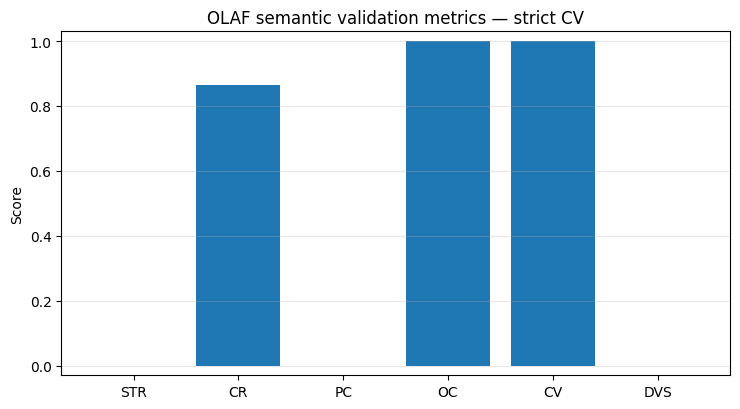

Saved: C:\Users\henri\Documents\git\post-doc\NeoOLAF\examples\XQualityMachine32\runs\olaf_semantic_validation_metrics_v2_strict_cv\olaf_semantic_validation_metrics_v2_strict_cv.png


In [9]:

import matplotlib.pyplot as plt

plot_df = slide_df.melt(id_vars='series', var_name='metric', value_name='score')

fig, ax = plt.subplots(figsize=(7.5, 4.2))
ax.bar(plot_df['metric'], plot_df['score'])
ax.set_ylim(-0.03, 1.03)
ax.set_title('OLAF semantic validation metrics — strict CV')
ax.set_ylabel('Score')
ax.grid(True, axis='y', alpha=0.3)
fig.tight_layout()
plot_path = OUTPUT_DIR / 'olaf_semantic_validation_metrics_v2_strict_cv.png'
fig.savefig(plot_path, dpi=180)
plt.show()
print('Saved:', plot_path)
